# Дискриминантный анализ

**Описание набора данных**

*Предикторы (признаки):*
1. Hemoglobin_g_L - концентрация гемоглобина в крови (г/л);
2. RBC_10e12_L - количество эритроцитов (10^12/л);
3. Color_Index - цветовой показатель крови;
4. Platelets_10e9_L — количество тромбоцитов (10⁹/л)
5. WBC_10e9_L — количество лейкоцитов (10⁹/л)
6. Neutrophils_% — процент нейтрофилов
7. Lymphocytes_% — процент лимфоцитов
8. ESR_mm_h — скорость оседания эритроцитов (мм/ч)

*Зависимая (целевая) переменная:*
**Health_Status**

    1. Healthy - условно здоров;
    2. Inflammation - воспалительный процесс;
    3. Anemia - анемия

10000 наблюдений.

# Предварительный анализ данных

In [ ]:
#загрузка библиотек

import pandas as pd
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#просмотр данных

url = "https://raw.githubusercontent.com/Oplot/Blood_Health_Dataset/main/blood_test_health.csv"
df = pd.read_csv(url)

print(df)

      Hemoglobin_g_L  RBC_10e12_L  Color_Index  Platelets_10e9_L  WBC_10e9_L  \
0         149.584009     5.652225     0.977267        244.960600    6.830804   
1         144.601591     4.833015     0.948451        300.733129    5.494478   
2         135.472178     4.390225     1.029044        274.580927    7.363224   
3         151.069341     4.452569     1.028207        249.086155    4.542711   
4         142.788646     5.324547     0.970421        302.427957    5.829866   
...              ...          ...          ...               ...         ...   
9995      144.900229     5.204710     0.902422        193.564550   11.204012   
9996      130.386927     4.196850     0.920137        239.580411   10.453077   
9997      129.502707     4.220708     0.925534        319.867708   15.020053   
9998      178.253508     4.613494     0.950031        268.036560   11.006236   
9999      154.427034     4.545866     0.860772        306.574070    6.858002   

      Neutrophils_%  Lymphocytes_%   ES

При первичном осмотре данных аномалии не были замечены. Количество наблюдений 10000, 8 предикторов и 1 зависимая переменная.

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Hemoglobin_g_L    10000 non-null  float64
 1   RBC_10e12_L       10000 non-null  float64
 2   Color_Index       10000 non-null  float64
 3   Platelets_10e9_L  10000 non-null  float64
 4   WBC_10e9_L        10000 non-null  float64
 5   Neutrophils_%     10000 non-null  float64
 6   Lymphocytes_%     10000 non-null  float64
 7   ESR_mm_h          10000 non-null  float64
 8   Health_Status     10000 non-null  object 
dtypes: float64(8), object(1)
memory usage: 703.3+ KB
None


Пропущенных значений нет.

In [ ]:
#Проверка на наличие строк-дубликатов
duplicates = df.duplicated()
duplicate_indexes = duplicates[duplicates].index.tolist()
duplicate_indexes

[]

Строк-дубликатов нет, все наблюдения уникальны.

In [ ]:
#Проверка на предикторы с 1 уникальным значением
df.columns[df.nunique().eq(1)]

Index([], dtype='object')

Предикторы, которые могли бы иметь только 1 значение, отсутствуют.

In [ ]:
#Проверка уникальных значений
for columns in df:
  print(columns, df[columns].unique())

Hemoglobin_g_L [149.58400899 144.60159108 135.47217796 ... 129.502707   178.25350767
 154.42703353]
RBC_10e12_L [5.65222475 4.83301496 4.39022541 ... 4.22070768 4.61349421 4.5458663 ]
Color_Index [0.97726713 0.94845093 1.02904369 ... 0.925534   0.95003051 0.86077206]
Platelets_10e9_L [244.96060032 300.73312853 274.58092684 ... 319.86770835 268.03656037
 306.57407043]
WBC_10e9_L [ 6.83080376  5.49447786  7.36322419 ... 15.0200531  11.0062362
  6.85800185]
Neutrophils_% [ 49.9295454   47.27023471  51.86280292 ...  76.55167131 100.53469023
  65.60386023]
Lymphocytes_% [30.82336142 28.7995789  32.24013476 ... 11.64035123 38.03897319
 17.82411081]
ESR_mm_h [15.54138248  6.4171942   7.76542113 ... 32.50982834 39.25744952
 37.64134145]
Health_Status ['Healthy' 'Anemia' 'Inflammation']


pandas работает с ограничением на вывод максимального количества значений, это можно обойти, но у нас всё равно много наблюдений, поэтому и так будет сложно что-то проанализировать глазами и найти "странные" значения.

In [ ]:
#Посмотрим на описательные статистики
df.describe().round(2)

,Hemoglobin_g_L,RBC_10e12_L,Color_Index,Platelets_10e9_L,WBC_10e9_L,Neutrophils_%,Lymphocytes_%,ESR_mm_h
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,130.36,4.49,0.88,281.80,7.65,57.91,29.11,15.16
std,21.73,0.69,0.13,56.04,2.30,11.23,8.53,11.31
min,59.36,2.09,0.41,88.06,1.54,26.25,-0.36,-6.43
25%,116.85,4.05,0.81,243.43,6.05,49.98,23.45,7.32
50%,134.38,4.58,0.91,276.00,7.16,56.92,29.33,11.64
75%,144.46,4.96,0.97,315.32,8.77,65.13,34.81,20.33
max,214.10,7.45,1.41,554.84,17.23,103.15,60.44,71.48


Уже здесь находим "странные" значения.

1. Lymphocytes_% (min = -0.36) - отрицательного значения не может быть в процентном соотношении в данной теме датасета;
2. ESR_mm_h (min = -6.43) - отрицательного значения не может быть по той же причине;
3. Neutrophils_% (max = 103.15) - процентное число не может превышать 100.

Анализ описательных статистик выявил наличие аномальных значений,
не соответствующих физиологическим ограничениям показателей
(отрицательные значения СОЭ и лимфоцитов, значения нейтрофилов свыше 100%).

Некоторые значения могут быть также крайне максимальными или крайне минимальными - требуется ещё более глубокий анализ выбросов.

In [ ]:
# Фильтрация невалидных наблюдений
df_clean = df[
    (df['Neutrophils_%'] > 0) & (df['Neutrophils_%'] <= 100) &
    (df['Lymphocytes_%'] > 0) & (df['Lymphocytes_%'] <= 100) &
    (df['ESR_mm_h'] >= 0)
]

print(df_clean.describe().round(2))

       Hemoglobin_g_L  RBC_10e12_L  Color_Index  Platelets_10e9_L  WBC_10e9_L  \
count         9854.00      9854.00      9854.00           9854.00     9854.00   
mean           130.30         4.49         0.88            281.98        7.66   
std             21.73         0.69         0.13             56.03        2.31   
min             59.36         2.09         0.41             88.06        1.54   
25%            116.78         4.05         0.80            243.63        6.07   
50%            134.31         4.57         0.91            276.27        7.17   
75%            144.41         4.96         0.97            315.53        8.81   
max            214.10         7.45         1.41            554.84       17.23   

       Neutrophils_%  Lymphocytes_%  ESR_mm_h  
count        9854.00        9854.00   9854.00  
mean           57.94          29.09     15.39  
std            11.21           8.54     11.18  
min            26.25           1.20      0.01  
25%            50.00          

In [ ]:
#Посмотрим на описательные статистики
df_clean.describe().round(2)

,Hemoglobin_g_L,RBC_10e12_L,Color_Index,Platelets_10e9_L,WBC_10e9_L,Neutrophils_%,Lymphocytes_%,ESR_mm_h
count,9854.00,9854.00,9854.00,9854.00,9854.00,9854.00,9854.00,9854.00
mean,130.30,4.49,0.88,281.98,7.66,57.94,29.09,15.39
std,21.73,0.69,0.13,56.03,2.31,11.21,8.54,11.18
min,59.36,2.09,0.41,88.06,1.54,26.25,1.20,0.01
25%,116.78,4.05,0.80,243.63,6.07,50.00,23.38,7.53
50%,134.31,4.57,0.91,276.27,7.17,56.94,29.33,11.77
75%,144.41,4.96,0.97,315.53,8.81,65.20,34.81,20.51
max,214.10,7.45,1.41,554.84,17.23,98.96,60.44,71.48


# Разведочный анализ

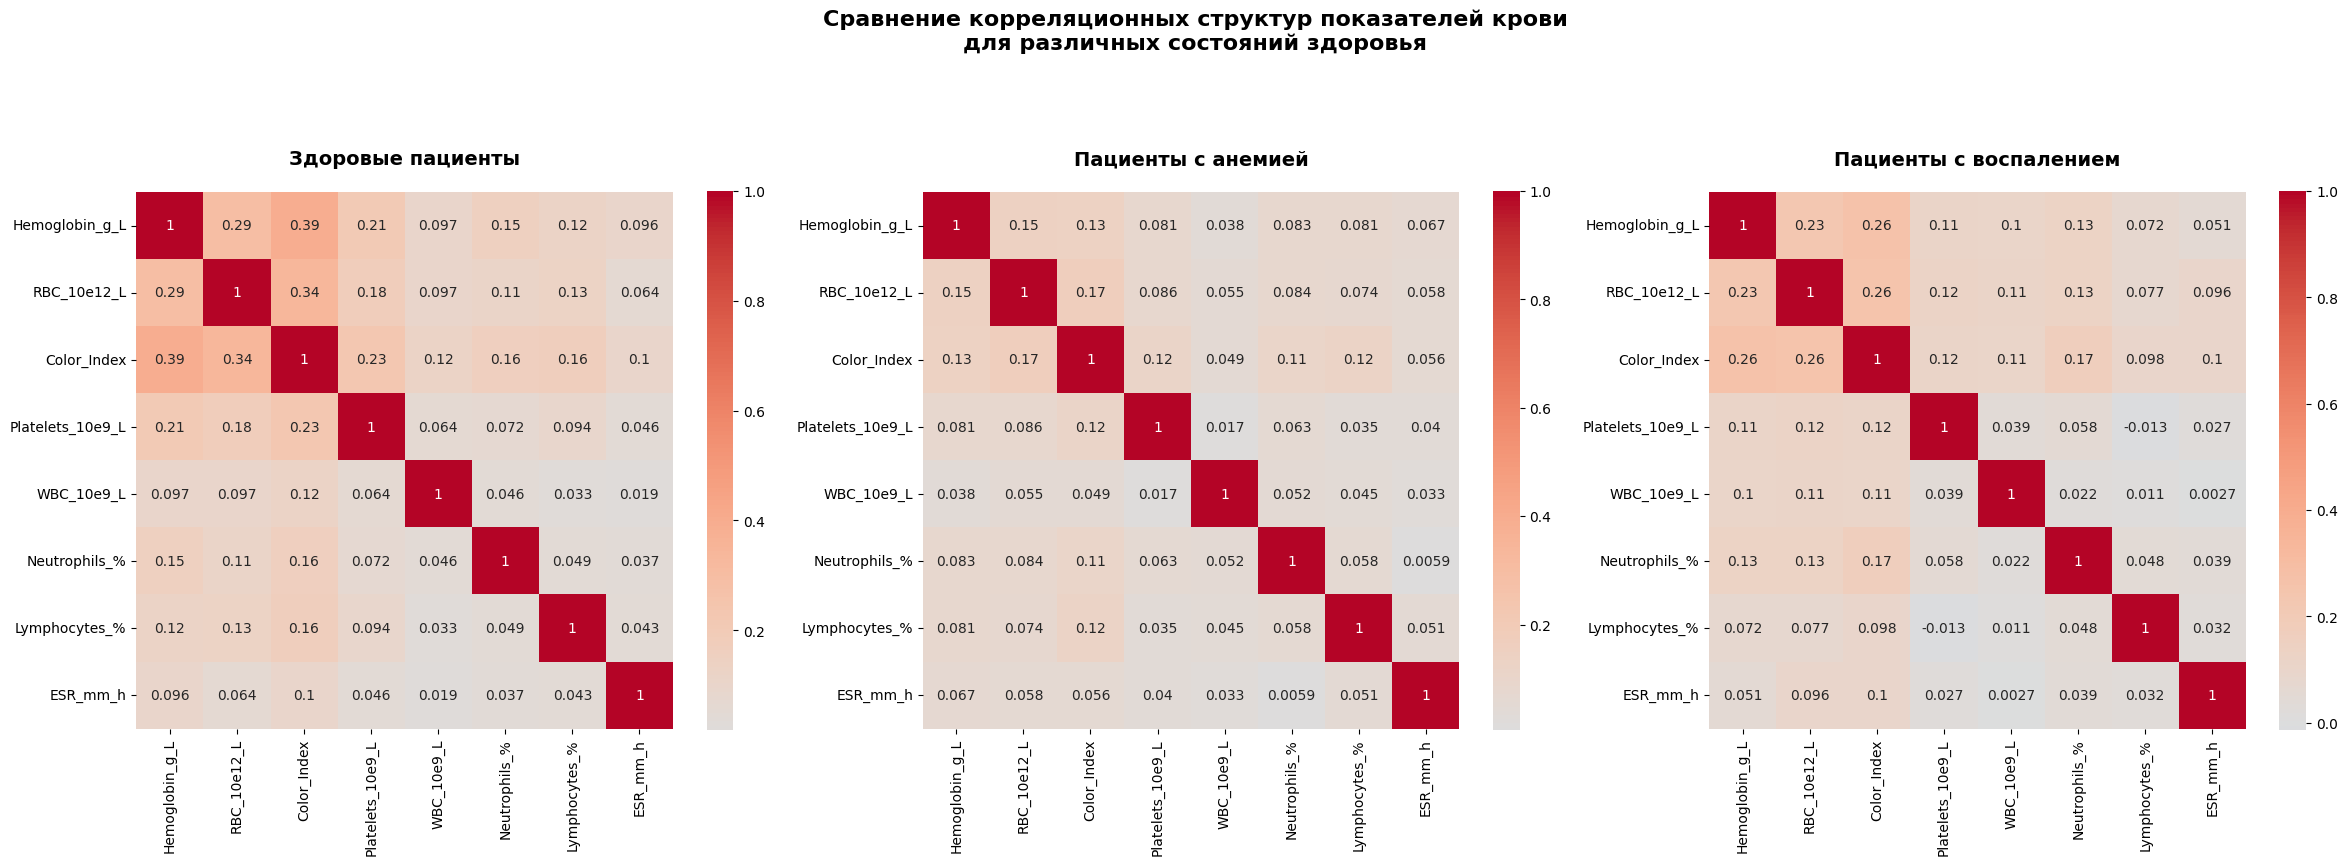

In [ ]:
# Список предикторов
predictors = [col for col in df_clean.columns if col != "Health_Status"]

# Разделение данных по группам
df_healthy = df_clean[df_clean["Health_Status"] == "Healthy"]
df_anemia = df_clean[df_clean["Health_Status"] == "Anemia"]
df_inflammation = df_clean[df_clean["Health_Status"] == "Inflammation"]

# Визуализация корреляционных матриц
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

groups = [
    (df_healthy, "Здоровые пациенты"),
    (df_anemia, "Пациенты с анемией"),
    (df_inflammation, "Пациенты с воспалением")
]

for ax, (data, title) in zip(axes, groups):
    sns.heatmap(
        data[predictors].corr(),
        annot=True,
        cmap="coolwarm",
        center=0,
        square=True,
        cbar_kws={"shrink": 0.8},
        ax=ax
    )
    ax.set_title(title, fontsize=14, fontweight="bold", pad=20)
    ax.tick_params(axis='x', rotation=90)
    ax.tick_params(axis='y', rotation=0)

fig.suptitle(
    "Сравнение корреляционных структур показателей крови\nдля различных состояний здоровья",
    fontsize=16,
    fontweight="bold",
    y=1.05
)

plt.tight_layout()
plt.show()


Во всех группах здоровья сильная мультиколлинеарность отсутствует.
Корреляционные структуры различаются между здоровыми пациентами, пациентами с анемией и пациентами с воспалительными процессами.
Наиболее выраженные взаимосвязи наблюдаются между эритроцитарными показателями (гемоглобин, количество эритроцитов, цветовой показатель), особенно у здоровых пациентов.
В группах с патологией (анемия и воспаление) данные связи ослаблены, что указывает на изменение физиологических механизмов регуляции крови.

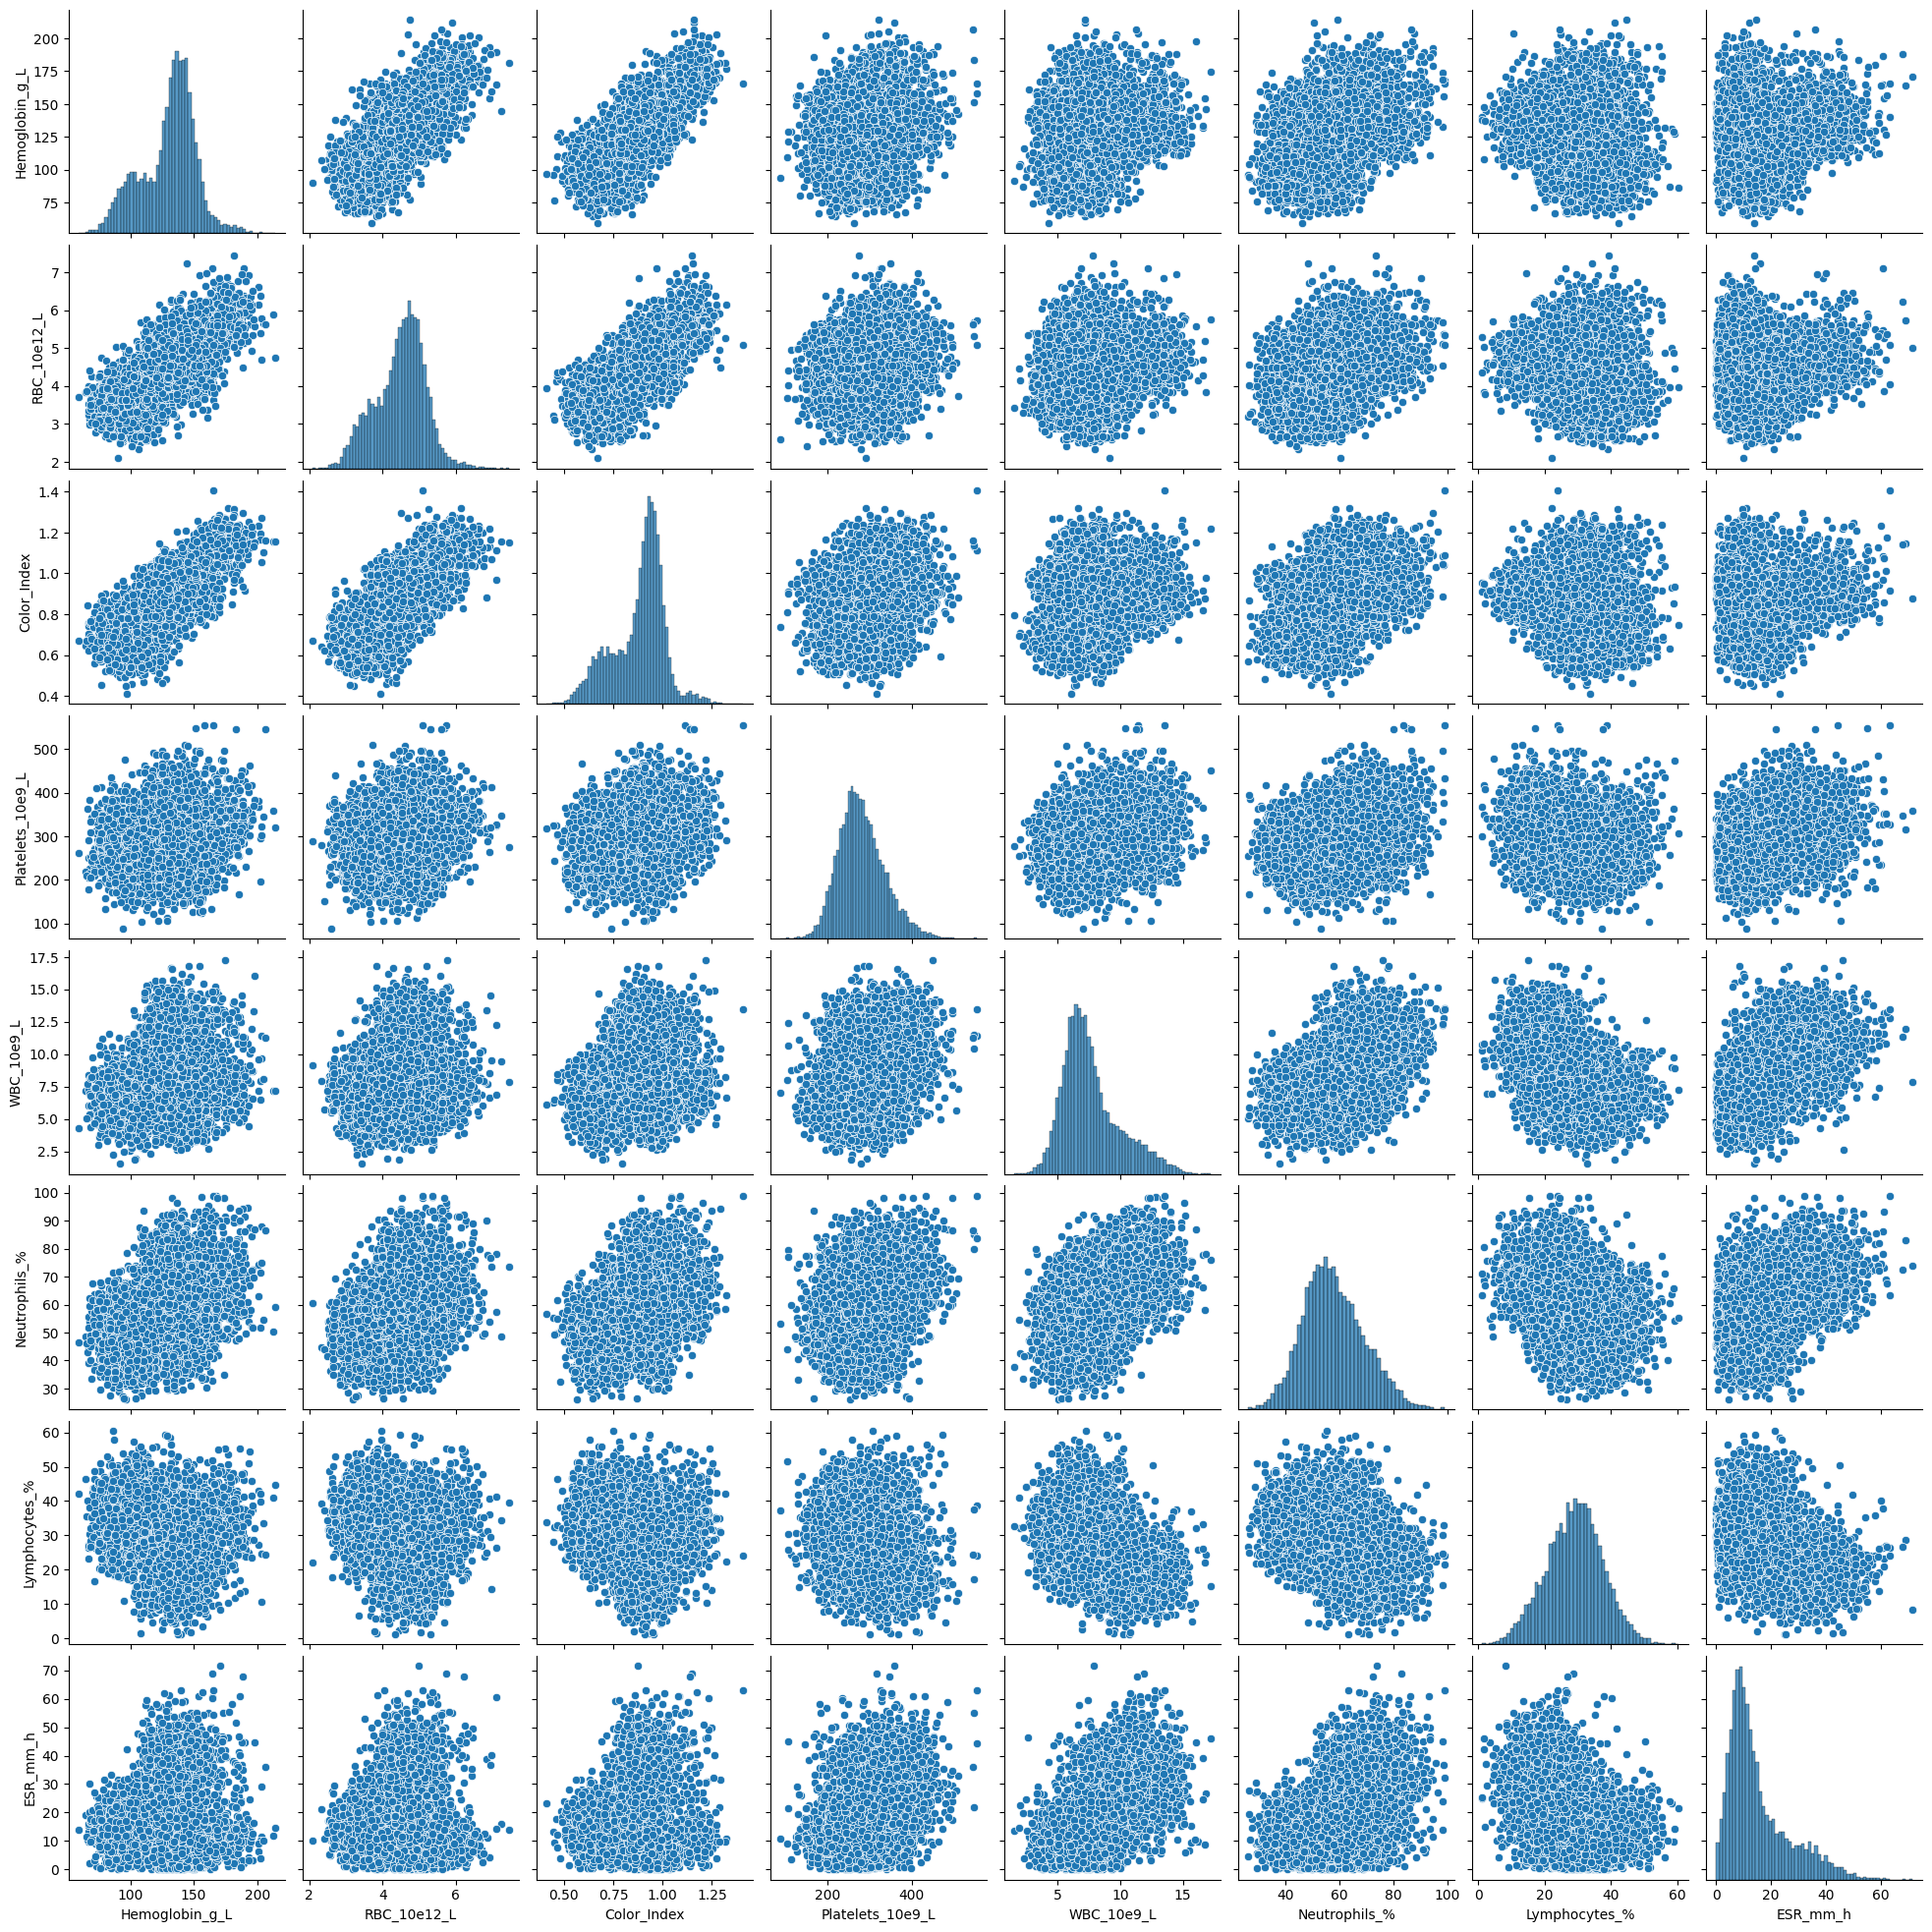

In [ ]:
#Диаграммы рассеяния
sns.pairplot(df_clean)
plt.show()

Связи между показателями общего анализа крови в целом являются слабыми или умеренными. Существенная мультиколлинеарность между признаками отсутствует. Наиболее выраженные зависимости наблюдаются между гемоглобином, количеством эритроцитов и цветовым показателем, что соответствует физиологическим особенностям крови.

Показатели лейкоцитарной формулы демонстрируют ожидаемую обратную связь между нейтрофилами и лимфоцитами. Большинство количественных признаков имеют распределения, близкие к нормальному, либо умеренно асимметричные.

Проведём ковариационный анализ

In [ ]:
# ковариация по предикторам
df_clean[predictors].cov()

,Hemoglobin_g_L,RBC_10e12_L,Color_Index,Platelets_10e9_L,WBC_10e9_L,Neutrophils_%,Lymphocytes_%,ESR_mm_h
Hemoglobin_g_L,472.312536,10.253787,2.085749,46.262601,6.432105,77.015265,-45.043516,-4.074195
RBC_10e12_L,10.253787,0.474923,0.063594,1.227841,0.174605,2.190953,-1.218145,-0.243820
Color_Index,2.085749,0.063594,0.017068,0.143023,0.027364,0.430784,-0.226655,-0.085373
Platelets_10e9_L,46.262601,1.227841,0.143023,3139.184499,43.479172,174.996459,-87.642740,230.066855
WBC_10e9_L,6.432105,0.174605,0.027364,43.479172,5.325016,12.807745,-8.494753,15.467841
Neutrophils_%,77.015265,2.190953,0.430784,174.996459,12.807745,125.627716,-39.293056,59.172908
Lymphocytes_%,-45.043516,-1.218145,-0.226655,-87.642740,-8.494753,-39.293056,73.006458,-38.494509
ESR_mm_h,-4.074195,-0.243820,-0.085373,230.066855,15.467841,59.172908,-38.494509,125.075529


Ковариационный анализ показал наличие логически обоснованных взаимосвязей между показателями крови.
Положительные ковариации между уровнем гемоглобина, числом эритроцитов и цветовым показателем отражают согласованность эритроцитарных характеристик.
Показатели иммунного ответа (лейкоциты, нейтрофилы, СОЭ) демонстрируют взаимосвязи, характерные для воспалительных процессов.

Отрицательные ковариации между долей нейтрофилов и лимфоцитов указывают на перераспределение лейкоцитарной формулы при различных состояниях здоровья.

Существенной мультиколлинеарности между предикторами не выявлено, что подтверждает корректность выбора признаков и целесообразность применения линейного дискриминантного анализа.

In [ ]:
#Выведем по 1 предиктору
px.box(df_clean[['Hemoglobin_g_L']])

Кажется, что выбросы есть, но их нет по медицинским показаниям.
Гемоглобин = 214 г/л может действительно встретиться у людей с полицитемией, обезвоживанием, болезнями сердца/легких.
Гемоглобин = 59 г/л говорит о тяжёлой степени анемии.

In [ ]:
px.box(df_clean[['RBC_10e12_L']])

Показатель количества эритроцитов = 7,5 - выше нормы, говорит о возможной гипоксии, обезвоживании.

Значение =2 - ниже нормы, но тоже может встертиться среди пациентов.

In [ ]:
px.box(df_clean[['Color_Index']])

Норма цветового показателя крови (ЦП) составляет примерно 0,8-1,1, показывая насыщенность эритроцитов гемоглобином: ниже 0,8 — гипохромная анемия (дефицит железа), выше 1,0 — гиперхромная (дефицит B12/фолиевой кислоты).

In [ ]:
px.box(df_clean[['Platelets_10e9_L']])

Что означают отклонения:

Тромбоцитопения (ниже 150 * 10^/л): Повышенный риск кровотечений, может быть при анемии, инфекциях, лейкозах.

Тромбоцитоз (выше 400-450 * 10^/л): Повышенный риск тромбозов, может быть признаком воспалений, инфекций, онкологии или стресса.

In [ ]:
px.box(df_clean[['WBC_10e9_L']])

Норма лейкоцитов (белых кровяных телец) у взрослых обычно составляет 4,0–11,0 * 10^9/л (иногда указывают 4,5–11,3 * 10^9/л или 4-9 * 10^9/л), но значения могут варьироваться в зависимости от возраста.

Что означают отклонения?

Лейкоцитоз (повышение): Инфекции (бактериальные), воспаления, стресс, травмы, беременность, прием некоторых лекарств.

Лейкопения (понижение): Вирусные инфекции, проблемы с иммунитетом, прием стероидов, гиповитаминозы.

In [ ]:
px.box(df_clean[['Neutrophils_%']])

Норма нейтрофилов в процентах зависит от возраста: у взрослых это обычно 47-72% (сегментоядерных), а у детей диапазон шире и меняется с возрастом: у новорожденных до 40-50%, у детей 1-12 лет - примерно 23-57%.

Отклонения могут быть вызваны воспалениями, инфекциями, стрессом или приемом лекарств, поэтому анализ всегда интерпретирует врач, учитывая общее состояние и другие показатели.

In [ ]:
px.box(df_clean[['Lymphocytes_%']])

Процент лимфоцитов "1-2" или 1-2% в общем анализе крови сильно ниже нормы (для взрослых норма 19-37% или 1-4,8 х 10^9/л) и указывает на лимфопению (снижение лимфоцитов), что говорит о проблемах с иммунитетом, возможно, из-за вирусных инфекций, тяжелых болезней, приеме некоторых лекарств или иммунодефицита.

А 60% характерно для детей, у которых норма 50-70% в возрасте до 1 года

In [ ]:
px.box(df_clean[['ESR_mm_h']])

Значение СОЭ (скорость оседания эритроцитов) 71 мм/ч очень высокое и значительно превышает норму для любого возраста и пола (обычно до 20-30 мм/ч), указывая на выраженное воспаление, инфекцию, аутоиммунное или онкологическое заболевание. Может достигать 100 мм/ч и более при гемобластозах (лейкоз, миелома)

По итогу, все "странные" значения были удалены ещё почти в самом начале. Здесь же выбросов нет. Все значения, которые кажутся выбросами в методе усов, являются реальными значениями при острых, крайне тяжёлых состояниях человека.

In [ ]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 9854 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Hemoglobin_g_L    9854 non-null   float64
 1   RBC_10e12_L       9854 non-null   float64
 2   Color_Index       9854 non-null   float64
 3   Platelets_10e9_L  9854 non-null   float64
 4   WBC_10e9_L        9854 non-null   float64
 5   Neutrophils_%     9854 non-null   float64
 6   Lymphocytes_%     9854 non-null   float64
 7   ESR_mm_h          9854 non-null   float64
 8   Health_Status     9854 non-null   object 
dtypes: float64(8), object(1)
memory usage: 769.8+ KB
None


Осталось 9854 наблюдения после удаления "странных" значений.

**Подготовка данных к моделированию**

In [ ]:
# Оставляем последние 5 наблюдений для прогноза
df_model = df_clean.iloc[:-5]
df_future = df_clean.iloc[-5:]

X = df_model.drop("Health_Status", axis=1)
y = df_model["Health_Status"]

In [ ]:
print(y)

0            Healthy
1            Healthy
2            Healthy
3            Healthy
4            Healthy
            ...     
9989    Inflammation
9990    Inflammation
9991    Inflammation
9992    Inflammation
9993    Inflammation
Name: Health_Status, Length: 9849, dtype: object


In [ ]:
print(X)

      Hemoglobin_g_L  RBC_10e12_L  Color_Index  Platelets_10e9_L  WBC_10e9_L  \
0         149.584009     5.652225     0.977267        244.960600    6.830804   
1         144.601591     4.833015     0.948451        300.733129    5.494478   
2         135.472178     4.390225     1.029044        274.580927    7.363224   
3         151.069341     4.452569     1.028207        249.086155    4.542711   
4         142.788646     5.324547     0.970421        302.427957    5.829866   
...              ...          ...          ...               ...         ...   
9989      131.059666     4.534928     0.942823        354.343293   12.786103   
9990      141.679427     4.728951     0.979548        278.748142    8.666422   
9991      139.032332     4.330788     1.005607        383.495823    8.962430   
9992      137.851828     4.365819     0.878335        309.945558   10.512595   
9993      128.859990     4.206134     0.979025        331.024059    7.800831   

      Neutrophils_%  Lymphocytes_%   ES

In [ ]:
# Стандартизация
scaler_standard = MinMaxScaler()
X_standard = scaler_standard.fit_transform(X)
X = X_standard

print(X)

[[0.58304599 0.66419556 0.56799726 ... 0.3257022  0.49999416 0.21735345]
 [0.55084805 0.51135508 0.53905084 ... 0.28912716 0.46583206 0.08968459]
 [0.49185092 0.42874355 0.62000781 ... 0.3522914  0.52390976 0.10854945]
 ...
 [0.51485775 0.41765425 0.59646474 ... 0.50233863 0.40326283 0.46242925]
 [0.50722897 0.4241901  0.468618   ... 0.7084547  0.30281628 0.3977525 ]
 [0.44912089 0.39439741 0.56976296 ... 0.71445918 0.39430529 0.5489515 ]]


In [ ]:
#Разделим на тестовую и тренировочную выборку
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

# Линейный дискриминантный анализ (LDA)

Обучение модели

In [ ]:
model = LinearDiscriminantAnalysis()
model.fit(x_train, y_train)

LinearDiscriminantAnalysis()

Делаем предсказание. Выводим точность тестовой и тренировочной выборок.

In [ ]:
y_pred = model.predict(x_test)
y_pred2 = model.predict(x_train)
print(f'Classification Report Test: \n{classification_report(y_test, y_pred)}')
print(f'Classification Report Train: \n{classification_report(y_train, y_pred2)}')

Classification Report Test: 
              precision    recall  f1-score   support

      Anemia       1.00      0.98      0.99       510
     Healthy       0.98      1.00      0.99       955
Inflammation       1.00      0.98      0.99       505

    accuracy                           0.99      1970
   macro avg       0.99      0.99      0.99      1970
weighted avg       0.99      0.99      0.99      1970

Classification Report Train: 
              precision    recall  f1-score   support

      Anemia       1.00      0.98      0.99      2048
     Healthy       0.98      1.00      0.99      3902
Inflammation       0.99      0.98      0.99      1929

    accuracy                           0.99      7879
   macro avg       0.99      0.99      0.99      7879
weighted avg       0.99      0.99      0.99      7879



Модель классифицирует все три класса очень хорошо

1. Precision ≈ 0.98–1.00

2. Recall ≈ 0.98–1.00

3. F1-score ≈ 0.99


Отсутствие переобучения:

1. Accuracy на train ≈ test

2. Метрики по классам практически совпадают

Баланс классов сохранён

1. Support по классам:

2. Healthy — больше

3. Anemia и Inflammation — сопоставимы

Нет сильного дисбаланса, поэтому:

1. macro avg ≈ weighted avg

2. метрики не искажены


Линейный дискриминантный анализ показал высокую точность классификации для всех трёх состояний здоровья. Значения precision, recall и F1-score близки к единице как на обучающей, так и на тестовой выборках, что свидетельствует об отсутствии переобучения и хорошей обобщающей способности модели.

Визуализируем предсказания модели

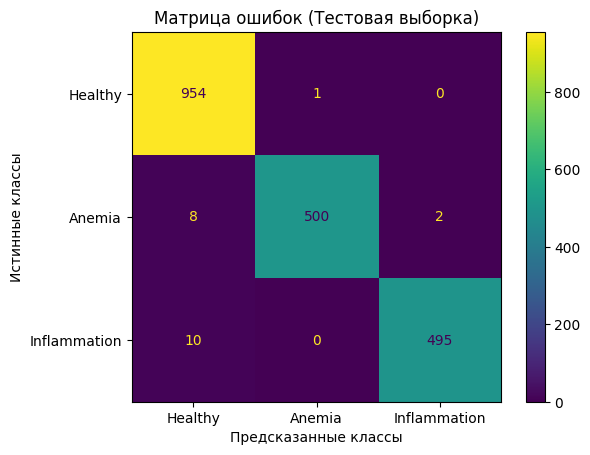

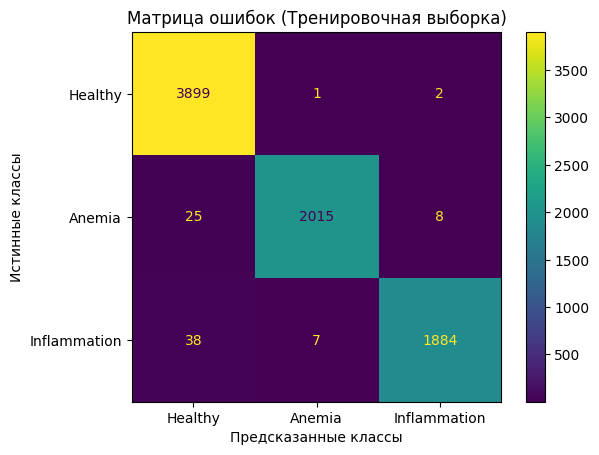

In [ ]:
# Явно задаём порядок классов
class_labels = ["Healthy", "Anemia", "Inflammation"]

# Матрицы ошибок
lda_test = confusion_matrix(y_test, y_pred, labels=class_labels)
lda_train = confusion_matrix(y_train, y_pred2, labels=class_labels)

# ТЕСТОВАЯ ВЫБОРКА
disp_test = ConfusionMatrixDisplay(
    confusion_matrix=lda_test,
    display_labels=class_labels
)
disp_test.plot(cmap="viridis")
plt.xlabel("Предсказанные классы")
plt.ylabel("Истинные классы")
plt.title("Матрица ошибок (Тестовая выборка)")
plt.show()

# ТРЕНИРОВОЧНАЯ ВЫБОРКА
disp_train = ConfusionMatrixDisplay(
    confusion_matrix=lda_train,
    display_labels=class_labels
)
disp_train.plot(cmap="viridis")
plt.xlabel("Предсказанные классы")
plt.ylabel("Истинные классы")
plt.title("Матрица ошибок (Тренировочная выборка)")
plt.show()

Матрица ошибок для тестовой выборки демонстрирует очень высокое качество классификации:

1. Абсолютное большинство наблюдений расположено на главной диагонали
2. Количество ошибок минимально относительно общего числа объектов
3. Классы хорошо разделимы в пространстве признаков

Это говорит о том, что линейный дискриминантный анализ адекватно описывает структуру данных

Healthy
1. 954 объектов классифицированы верно
2. 1 объект ошибочно отнесён к Anemia
3. 0 ошибок в класс Inflammation

Anemia
1. 500 объектов классифицированы верно
2. 8 объектов ошибочно отнесены к Healthy
3. 2 — к Inflammation

Inflammation
1. 495 объектов классифицированы верно
2. 10 объектов ошибочно отнесены к Healthy
3. 0 — к Anemia

Класс Healthy распознаётся моделью практически идеально. Ошибки носят единичный характер, что говорит о чётком отделении здоровых пациентов от патологических состояний.

Ошибки для класса Anemia встречаются чаще, чем для Healthy, однако их доля остаётся крайне низкой. Небольшое число ошибок можно объяснить пограничными значениями гематологических показателей, характерных как для анемии, так и для нормы или воспалительных процессов.

Класс Inflammation также определяется с высокой точностью. Основной источник ошибок — смешение с классом Healthy, что может быть связано с начальными или слабо выраженными воспалительными процессами.

Предсказания на исключённых ранее данных

In [ ]:
# Осуществим предсказания для исключённых ранее наблюдений
X_future = df_clean.iloc[-5:].drop("Health_Status", axis=1)

predictions = model.predict(X_future)

print("Предсказанные классы:", predictions)
print()
print(df_clean.iloc[-5:])


Предсказанные классы: ['Inflammation' 'Inflammation' 'Inflammation' 'Inflammation'
 'Inflammation']

      Hemoglobin_g_L  RBC_10e12_L  Color_Index  Platelets_10e9_L  WBC_10e9_L  \
9994      125.459731     4.462341     0.953851        230.207678    9.791352   
9995      144.900229     5.204710     0.902422        193.564550   11.204012   
9996      130.386927     4.196850     0.920137        239.580411   10.453077   
9997      129.502707     4.220708     0.925534        319.867708   15.020053   
9999      154.427034     4.545866     0.860772        306.574070    6.858002   

      Neutrophils_%  Lymphocytes_%   ESR_mm_h Health_Status  
9994      60.498970      18.141239  37.277031  Inflammation  
9995      70.123732      24.077442  25.983723  Inflammation  
9996      60.229642      19.058025  31.293573  Inflammation  
9997      76.551671      11.640351  32.509828  Inflammation  
9999      65.603860      17.824111  37.641341  Inflammation  


По результатам прогнозирования все наблюдения были отнесены к классу Inflammation, что полностью совпадает с их реальными значениями целевой переменной. Это свидетельствует о способности модели корректно распознавать характерные паттерны воспалительных состояний на основе лабораторных показателей крови.

# Заключение

Дискриминантный анализ является мощным и интерпретируемым инструментом классификации, позволяющим выявлять и объяснять различия между группами объектов. В сфере медицины он особенно ценен благодаря способности работать с количественными клиническими показателями и предоставлять прозрачные результаты, которые могут быть использованы для поддержки диагностических решений. Проведённое исследование подтвердило целесообразность применения линейного дискриминантного анализа для классификации состояний здоровья на основе лабораторных показателей крови.